In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42  # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"


In [2]:
# TODO: Load the taxi dataset from TAXI_URL into a DataFrame called `taxi`
taxi = pd.read_csv(TAXI_URL)

# TODO: Inspect it
# - taxi.shape, taxi.head(), taxi.info()
# - taxi.describe()
# - count missing values per column: taxi.isna().sum()

print(taxi.shape)
taxi.head()

# TODO: Visualise the distribution of the target `tip_amount`
#   (e.g. sns.histplot). Comment on its shape and any extreme values.

(41202, 13)


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
0,2,1,17.63,2,1,132,164,1,70.0,0.5,6.94,1,16.54
1,2,1,19.52,2,1,132,236,1,70.0,0.5,6.94,1,16.19
2,2,1,17.81,2,1,132,48,1,70.0,0.5,6.94,1,12.00
3,2,2,19.30,2,1,132,148,1,70.0,0.5,0.00,1,5.00
4,2,1,18.75,2,1,132,234,1,70.0,0.5,6.94,1,10.00


In [3]:
taxi.info()

<class 'pandas.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB


In [4]:
taxi.describe()

,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
count,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000
mean,2.0,1.633926,18.384928,2.025411,0.999393,132.220475,164.546333,1.0,69.986150,0.491020,5.608198,0.999976,14.107666
std,0.0,0.924250,2.856605,0.461587,0.024625,7.726159,67.901529,0.0,6.184851,0.066404,2.979348,0.004927,5.030619
min,2.0,1.000000,0.000000,1.000000,0.000000,10.000000,3.000000,1.0,3.700000,0.000000,0.000000,0.000000,0.010000
25%,2.0,1.000000,17.370000,2.000000,1.000000,132.000000,113.000000,1.0,70.000000,0.500000,6.940000,1.000000,10.000000
50%,2.0,1.000000,18.180000,2.000000,1.000000,132.000000,163.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
75%,2.0,2.000000,19.380000,2.000000,1.000000,132.000000,231.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
max,2.0,8.000000,189.910000,5.000000,1.000000,264.000000,265.000000,1.0,199.700000,0.500000,57.000000,1.000000,98.000000


In [5]:
taxi.isna().sum()

VendorID                 0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
mta_tax                  0
tolls_amount             0
improvement_surcharge    0
tip_amount               0
dtype: int64

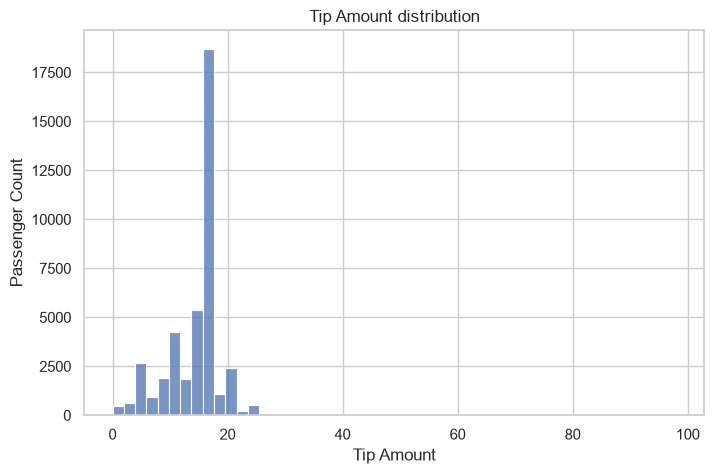

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(taxi["tip_amount"], bins=50)
plt.title("Tip Amount distribution")
plt.ylabel("Passenger Count")
plt.xlabel("Tip Amount")
plt.show()


Student Reasoning — Taxi data exploration 

What is the shape of the data? 
The data has 41,202 rows and 13 columns.

Are there missing values or impossible values (e.g. negative tips, zero-distance trips)?
There are no missing or impossible values in the data.

What does the tip_amount distribution look like (skew, outliers, many zeros)? How will this influence your preprocessing?
The tip_amount distribution is left (negative) skewed because the Mean is lower than the Median,there are outliers (for instance $98). The outliers may distort the data calculations and analysis.
For preprocessing, we may need to remove invalid / impossible values and extreme outliers from the dataset

In [7]:
# TODO: Handle missing / invalid rows
#   e.g. drop or impute NaNs; remove rows where trip_distance <= 0 or fare_amount <= 0;
#   decide how to treat negative tip_amount values.

# TODO: Feature engineering — create at least ONE new, justified feature, for example:
#   - tip_rate proxy, fare-per-mile = fare_amount / trip_distance
#   - total surcharges = mta_tax + tolls_amount + improvement_surcharge
#   (Careful: do NOT leak the target. Do not build features directly from tip_amount.)

# TODO: Decide which columns are categorical (e.g. VendorID, RatecodeID, payment_type,
#   store_and_fwd_flag) vs numeric, and encode the categoricals (pd.get_dummies or OneHotEncoder).

# TODO: Scale the numeric features.
#   from sklearn.preprocessing import StandardScaler   (fit on TRAIN only — see Part 1.3)

In [ ]:
taxi = taxi[taxi["trip_distance"] > 0]
taxi = taxi[taxi["fare_amount"] > 0]
taxi = taxi[taxi["tip_amount"] >= 0]


In [ ]:
taxi["fare_per_mile"] = taxi["fare_amount"] / taxi["trip_distance"]
taxi["total_surcharges"] = (
    taxi["tolls_amount"] + taxi["mta_tax"] + taxi["improvement_surcharge"]
)


In [ ]:
categorical_columns = ["VendorID", "RatecodeID", "payment_type", "store_and_fwd_flag"]
taxi = pd.get_dummies(taxi, columns=categorical_columns)

In [ ]:
numeric_columns = [
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "mta_tax",
    "tolls_amount",
    "improvement_surcharge",
    "fare_per_mile",
    "total_surcharges",
]


Student Reasoning — Taxi preprocessing 
1. How did you handle missing/invalid rows and why? 
There were no missing rows in the dataset, but there were invalid / impossible values in some dataset columns (fare_amount < 0, trip_distance <0, tip_amount < 0). These values were removed. 

2. Which new feature(s) did you engineer and what is the intuition behind them? 
The new features engineered were fare_per_mile and total_surcharges. fare_per_mile returns trip amount relative to the trip distance while total_surcharges adds all the extra charges into one. 

3. Which scaling method did you choose and why is it appropriate here?
The scaling method used was StandardScaler. It is appropriate because the numeric features listed are on different scales, so this method prevents features with larger numerical ranges from dominating the training process.



In [ ]:
# TODO: Separate features (X) and target (y = tip_amount)

# TODO: Split into train / validation / test (a common choice is 60/20/20).
#   from sklearn.model_selection import train_test_split
#   First split off the test set, then split the remainder into train + validation.
#   Use random_state=RANDOM_STATE.

# TODO: Fit your scaler on the TRAINING set only, then transform train, val, and test.
#   (Explain in the reasoning box why scaling must be fit on train only.)

In [ ]:
X = taxi.drop(columns=["tip_amount"])
y = taxi["tip_amount"]


In [15]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_rem, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_rem, test_size=0.25, random_state=RANDOM_STATE
)


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])
X_val[numeric_columns] = scaler.transform(X_val[numeric_columns])
X_test[numeric_columns] = scaler.transform(X_test[numeric_columns])

Student Reasoning — Splitting 
What ratio did you use? 
A 60/20/20 ratio was used (60% train, 20% validation , 20% test)

Why is a separate validation set useful in addition to a test set?
A separate validation set is useful in addition to a test set because the validation set acts as a practice session where you can test performance without leaking test information to your model, so the final test is completely unbiased.

Why must the scaler (and any imputation statistics) be fit on the training data only?
The scaler must be fit on the training data only to prevent leakage. Fitting the scaler on the full dataset gives the agent an advantage during the test because statistics like mean and median are leaked. 

In [ ]:
# TODO: Import, initialise, and train a regression model.
#   Start simple (LinearRegression), then try a more flexible model
#   (e.g. RandomForestRegressor or DecisionTreeRegressor) and compare.

# TODO: Predict on train, validation, and test sets.

# TODO: Report RMSE and R^2 for ALL THREE sets.
#   from sklearn.metrics import mean_squared_error, r2_score
#   (RMSE = mean_squared_error(y_true, y_pred) ** 0.5)

# TODO: Plot predicted vs actual tip for the test set (a scatter with the y=x line).

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_train_prediction = lr.predict(X_train)
lr_val_prediction = lr.predict(X_val)
lr_test_prediction = lr.predict(X_test)

rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)

rf_train_prediction = rf.predict(X_train)
rf_val_prediction = rf.predict(X_val)
rf_test_prediction = rf.predict(X_test)


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_squared_error, r2_score

print("Logistic Regression")
lr_train_rmse = mean_squared_error(y_train, lr_train_prediction) ** 0.5
lr_train_r2 = r2_score(y_train, lr_train_prediction)
print("Train RMSE: ", round(lr_train_rmse, 4), ",  Train R2: ", round(lr_train_r2, 4))

lr_val_rmse = mean_squared_error(y_val, lr_val_prediction) ** 0.5
lr_val_r2 = r2_score(y_val, lr_val_prediction)
print(
    "Validation RMSE: ",
    round(lr_val_rmse, 4),
    ",  Validation R2: ",
    round(lr_val_r2, 4),
)

lr_test_rmse = mean_squared_error(y_test, lr_test_prediction) ** 0.5
lr_test_r2 = r2_score(y_test, lr_test_prediction)
print("Test RMSE: ", round(lr_test_rmse, 4), ",  Test R2: ", round(lr_test_r2, 4))
print()
print()
print("RandomForestRegressor")
rf_train_rmse = mean_squared_error(y_train, rf_train_prediction) ** 0.5
rf_train_r2 = r2_score(y_train, rf_train_prediction)
print("Train RMSE: ", round(rf_train_rmse, 4), ",  Train R2: ", round(rf_train_r2, 4))

rf_val_rmse = mean_squared_error(y_val, rf_val_prediction) ** 0.5
rf_val_r2 = r2_score(y_val, rf_val_prediction)
print(
    "Validation RMSE: ",
    round(rf_val_rmse, 4),
    ",  Validation R2: ",
    round(rf_val_r2, 4),
)

rf_test_rmse = mean_squared_error(y_test, rf_test_prediction) ** 0.5
rf_test_r2 = r2_score(y_test, rf_test_prediction)
print("Test RMSE: ", round(rf_test_rmse, 4), ",  Test R2: ", round(rf_test_r2, 4))

Train RMSE:  4.8045 ,  Train R2:  0.0513
Validation RMSE:  5.0371 ,  Validation R2:  0.0486
Test RMSE:  5.0132 ,  Test R2:  0.0511


Train RMSE:  2.8364 ,  Train R2:  0.6694
Validation RMSE:  5.647 ,  Validation R2:  -0.1957
Test RMSE:  5.611 ,  Test R2:  -0.1888


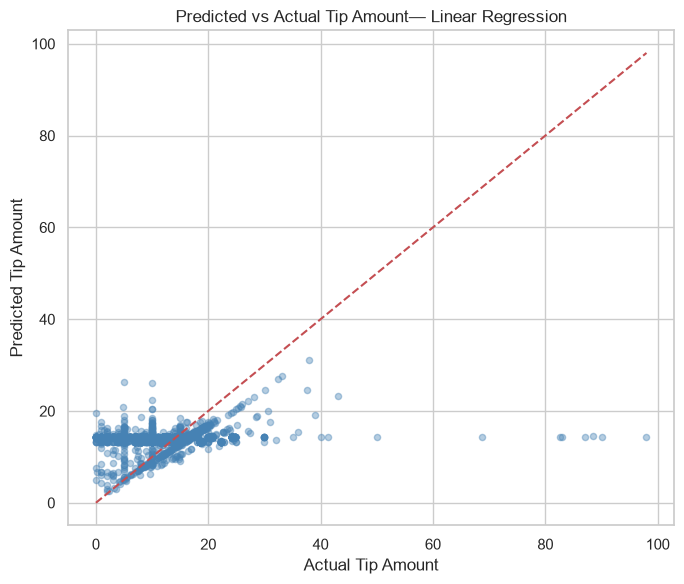

In [ ]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, lr_test_prediction, alpha=0.4, s=20, color="steelblue")
plt.plot(
    [y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", linewidth=1.5
)
plt.xlabel("Actual Tip Amount")
plt.ylabel("Predicted Tip Amount")
plt.title("Predicted vs Actual Tip Amount— Linear Regression")
plt.tight_layout()
plt.show()

Student Reasoning — Regression evaluation & overfitting 
1. Which model performed best on the validation set, and which hyper-parameters did you try? 
The two tests were Linear regression and Random forest and the linear Regression test performed better. The random forest test was tried with n_estimators = 100.

2. Compare TRAIN vs VALIDATION vs TEST metrics. Is the model overfitting, underfitting, or well-fitted? Quote the specific numbers that back up your claim. 
The Linear Regression model is underfitting with values, train: R^2 = 0.0511, validation: R^2 = 0.0486 and test: R^2 = 0.0513.

The Random forest model is overfitting with the values, train: R^2 = 0.6694,validation: R^2= -0.1957, and test: R^2 = -0.1888. 

3. What would you change to reduce overfitting if you saw it?
Limiting depth forces the tree to learn broader, more meaningful patterns rather than memorising individual rows. I would limit max depth and set a limit to where it is not to deep and too shallow at the same time


In [ ]:
# TODO: Load the obesity dataset from OBESITY_URL into a DataFrame called `obesity`

# TODO: Inspect shape, head, info, describe, and missing values.

# TODO: Show the class distribution of `NObeyesdad`
#   (value_counts and a sns.countplot). Is it balanced across the 7 classes?

In [23]:
obesity = pd.read_csv(OBESITY_URL)

In [24]:
print(obesity.shape)
obesity.head()

(2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [25]:
obesity.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

In [26]:
obesity.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [27]:
obesity.isna().sum()

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

In [28]:
print(obesity["NObeyesdad"].value_counts())

NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


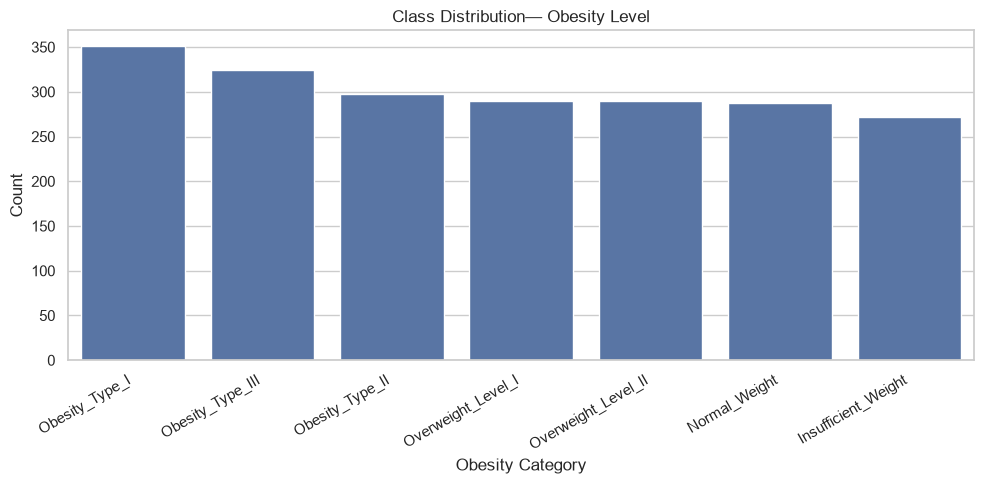

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=obesity, x="NObeyesdad", order=obesity["NObeyesdad"].value_counts().index
)
plt.title("Class Distribution— Obesity Level")
plt.xlabel("Obesity Category")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

Student Reasoning — Obesity data exploration 
How many rows/features are there? 
There are 2111 rows and 17 columns in the data.

Which columns are categorical vs numeric? 
The numerical columns are (age, height, weight, FCVC, NCP, FAF, TUE)
The categorical columns are (Gender, family_history_with_overweight, FAVC, CAEC, SMOKE, SCC, CALC, MTRANS, NObeyesdad)

Is the target balanced across the 7 classes, and why does class (im)balance matter for classification?
The target is reasonably balanced, as value counts range from 272(Insufficient_Weight) to 351(Obesity_Type_I). This matters because when one class outnumbers the others, the agent learns that the easiest way to get a low error rate is to predict the majority class and ignore the minority. 


In [ ]:
# TODO: Encode categorical columns.
#   - Binary yes/no columns (family_history_with_overweight, FAVC, SMOKE, SCC) -> 0/1
#   - Ordinal-ish columns (CAEC, CALC) and nominal (Gender, MTRANS) -> choose an encoding
#     and justify it (LabelEncoder / OrdinalEncoder / pd.get_dummies / OneHotEncoder).

# TODO (optional but encouraged): engineer a domain feature, e.g. BMI = Weight / Height**2.
#   Discuss whether including BMI makes the task "too easy" / leaks the target.

# TODO: Encode the target `NObeyesdad` into integer class labels
#   from sklearn.preprocessing import LabelEncoder

# TODO: Scale the numeric features (fit on TRAIN only, in Part 2.3).

In [ ]:
obesity["family_history_with_overweight"] = obesity[
    "family_history_with_overweight"
].map({"no": 0, "yes": 1})
obesity["FAVC"] = obesity["FAVC"].map({"no": 0, "yes": 1})
obesity["SMOKE"] = obesity["SMOKE"].map({"no": 0, "yes": 1})
obesity["SCC"] = obesity["SCC"].map({"no": 0, "yes": 1})


In [31]:
order_map = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}
obesity["CAEC"] = obesity["CAEC"].map(order_map)
obesity["CALC"] = obesity["CALC"].map(order_map)


In [32]:
obesity = pd.get_dummies(obesity, columns=["Gender", "MTRANS"])

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
obesity["NObeyesdad_encoded"] = le.fit_transform(obesity["NObeyesdad"])


In [35]:
numeric_columns = ["Age", "Height", "Weight", "FCVC", "NCP", "CH2O", "FAF", "TUE"]


Student Reasoning — Obesity preprocessing 
1. How did you encode each type of categorical variable, and why? 
For binary columns, they were mapped directly to 0/1, CAEC and CALC were encoded (0-3) to preserve the increasing order, and Gender and MTRANS were one hot encoded since they have no meaning ful order 

2. Did you engineer any feature (e.g. BMI)? Argue whether it is fair to include given the target is an obesity level. 
I did not engineer any feature like BMI because the feature is often used to classify the categories we are working with. The agent might learn this shortcut as well rather than learning from behaviour and lifestyle. 

3. Which scaler did you use and why?
The scaling method used was StandardScaler. It is appropriate because the numeric features listed are on different scales, so this method prevents features with larger numerical ranges from dominating the training process.


In [ ]:
# TODO: Separate X (features) and y (encoded NObeyesdad).

# TODO: Split into train / validation / test using stratify=y so every split has all 7 classes.
#   Use random_state=RANDOM_STATE.

# TODO: Fit the scaler on the training set only, then transform train / val / test.

In [36]:
X_ob = obesity.drop(columns=["NObeyesdad", "NObeyesdad_encoded"])
y_ob = obesity["NObeyesdad_encoded"]


In [37]:
from sklearn.model_selection import train_test_split

X_rem, X_test_ob, y_rem, y_test_ob = train_test_split(
    X_ob, y_ob, test_size=0.20, random_state=RANDOM_STATE, stratify=y_ob
)
X_train_ob, X_val_ob, y_train_ob, y_val_ob = train_test_split(
    X_rem, y_rem, test_size=0.25, random_state=RANDOM_STATE, stratify=y_rem
)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler_ob = StandardScaler()

X_train_ob[numeric_columns] = scaler_ob.fit_transform(X_train_ob[numeric_columns])
X_val_ob[numeric_columns] = scaler_ob.transform(X_val_ob[numeric_columns])
X_test_ob[numeric_columns] = scaler_ob.transform(X_test_ob[numeric_columns])

Student Reasoning — Splitting 
What split ratio did you choose? 
A 60/20/20 ratio was used (60% train, 20% validation , 20% test)

Why is stratify=y important for this dataset? 
Stratify prevents bias by dividing the samples evenly to ensure that the train and test split get the exact same percentage of samples for each of the seven classes.

What could go wrong if you split without stratifying?
if you split without stratifying, samples are divided randomly. This may result in severe imbalances in the split with minoity classes being underrepresented.

In [ ]:
# TODO: Import, initialise, and train a classifier
#   (e.g. LogisticRegression(max_iter=...), RandomForestClassifier, or KNeighborsClassifier).

# TODO: Predict on train, validation, and test.

# TODO: Report accuracy AND macro-F1 for ALL THREE sets
#   from sklearn.metrics import accuracy_score, f1_score, classification_report

# TODO: Show a confusion matrix for the test set
#   from sklearn.metrics import ConfusionMatrixDisplay
#   Which classes are most often confused?

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_ob, y_train_ob)

logreg_train_pred = logreg.predict(X_train_ob)
logreg_val_pred = logreg.predict(X_val_ob)
logreg_test_pred = logreg.predict(X_test_ob)

rf_c = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_c.fit(X_train_ob, y_train_ob)

rf_train_pred = rf_c.predict(X_train_ob)
rf_val_pred = rf_c.predict(X_val_ob)
rf_test_pred = rf_c.predict(X_test_ob)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

print("Logistic Regression")
print(
    "Train Accuracy: ",
    round(accuracy_score(y_train_ob, logreg_train_pred), 4),
    ",  Macro-F1: ",
    round(f1_score(y_train_ob, logreg_train_pred, average="macro"), 4),
)
print(
    "Validation Accuracy: ",
    round(accuracy_score(y_val_ob, logreg_val_pred), 4),
    ",  Macro-F1: ",
    round(f1_score(y_val_ob, logreg_val_pred, average="macro"), 4),
)
print(
    "Test Accuracy: ",
    round(accuracy_score(y_test_ob, logreg_test_pred), 4),
    ",  Macro-F1: ",
    round(f1_score(y_test_ob, logreg_test_pred, average="macro"), 4),
)
print()
print()
print("Random Forest")
print(
    "Train Accuracy: ",
    round(accuracy_score(y_train_ob, rf_train_pred), 4),
    ",  Macro-F1: ",
    round(f1_score(y_train_ob, rf_train_pred, average="macro"), 4),
)
print(
    "Validation Accuracy: ",
    round(accuracy_score(y_val_ob, rf_val_pred), 4),
    ",  Macro-F1: ",
    round(f1_score(y_val_ob, rf_val_pred, average="macro"), 4),
)
print(
    "Test Accuracy: ",
    round(accuracy_score(y_test_ob, rf_test_pred), 4),
    ",  Macro-F1: ",
    round(f1_score(y_test_ob, rf_test_pred, average="macro"), 4),
)

Logistic Regression
Train Accuracy:  0.9028 ,  Macro-F1:  0.8999
Validation Accuracy:  0.8602 ,  Macro-F1:  0.8526
Test Accuracy:  0.8652 ,  Macro-F1:  0.8602


Random Forest
Train Accuracy:  1.0 ,  Macro-F1:  1.0
Validation Accuracy:  0.9455 ,  Macro-F1:  0.9439
Test Accuracy:  0.9433 ,  Macro-F1:  0.943


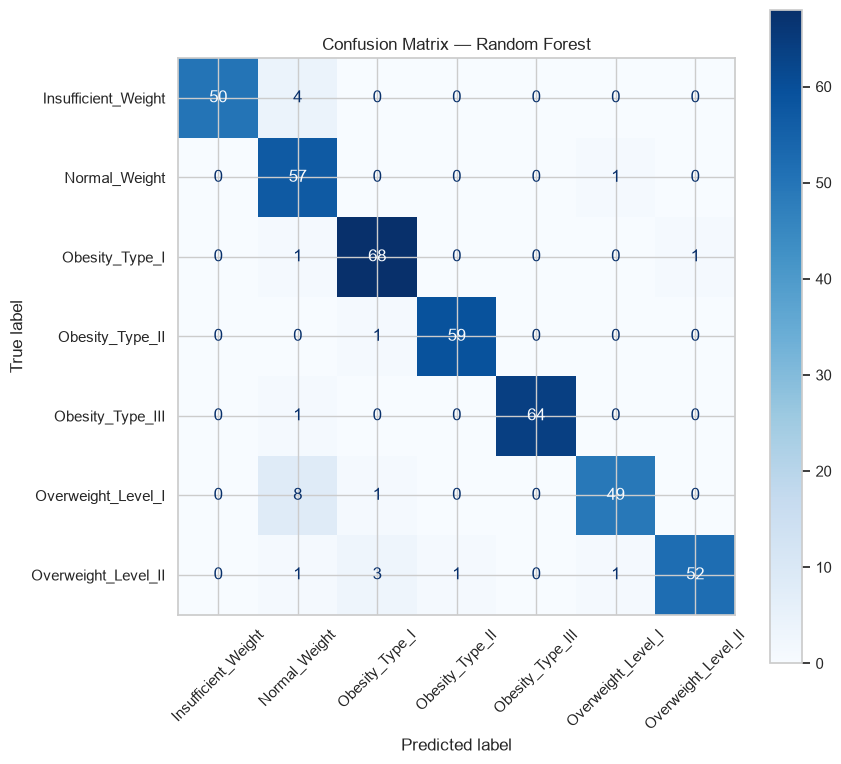

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test_ob,
    rf_test_pred,
    display_labels=le.classes_,
    xticks_rotation=45,
    cmap="Blues",
    ax=ax,
)
plt.title("Confusion Matrix — Random Forest")
plt.tight_layout()
plt.show()

Student Reasoning — Classification evaluation & overfitting 
1. Which classifier did you choose and why? 
The two tests were Logistic Regression an dRandom Forest. Random forest performed better on validation (Validation Accuracy:  0.9455 ,  Macro-F1:  0.9439) as compared to the Logistic Regression (Validation Accuracy:  0.8602 ,  Macro-F1:  0.8526). Hence the better choice is the Random Forest Classifier.

2. Compare TRAIN vs VALIDATION vs TEST accuracy/F1. Is the model overfitting, underfitting, or well-fitted? Cite the specific metrics. 
Logistic Regression had the vlaues (Train Accuracy: 0.9028,Validation Accuracy:  0.8602, Test Accuracy:  0.8652) with little variation, hence it is well fitted.
The random forest had the values (Train Accuracy: 1.0, Validation Accuracy: 0.9455, Test Accuracy: 0.9433 ) with a little drop and it still generalizes well so it is also well fitted.

3. From the confusion matrix, which obesity levels are hardest to tell apart, and why might that be?
The overweight level I and the Normal Weight were the hardest to tell apart because 8 out of the Overweight level I test cases were predicted as Normal weight. The agent found difficulty distinguishing Overweight level I from Normal weight.


In [ ]:
# TODO: Use ONLY the scaled obesity features (no target) for clustering.

# TODO: Choose the number of clusters k with the Elbow method (and/or silhouette score).
#   from sklearn.cluster import KMeans
#   from sklearn.metrics import silhouette_score
#   Loop k = 2..10, record inertia_ (and silhouette), and plot inertia vs k.

# TODO: Fit KMeans with your chosen k (random_state=RANDOM_STATE) and get cluster labels.

# TODO: Visualise the clusters in 2D.
#   Pick two informative features (e.g. Weight vs Height) OR reduce to 2D with PCA
#   (from sklearn.decomposition import PCA) and colour points by cluster.


In [ ]:
# TODO: How well do the clusters line up with the TRUE obesity levels?
#   Build a crosstab of cluster label vs the real NObeyesdad category:
#   pd.crosstab(cluster_labels, obesity['NObeyesdad'])
#   Do some clusters map cleanly onto specific obesity levels?

In [49]:
X_cluster = pd.concat([X_train_ob, X_val_ob, X_test_ob], axis=0)


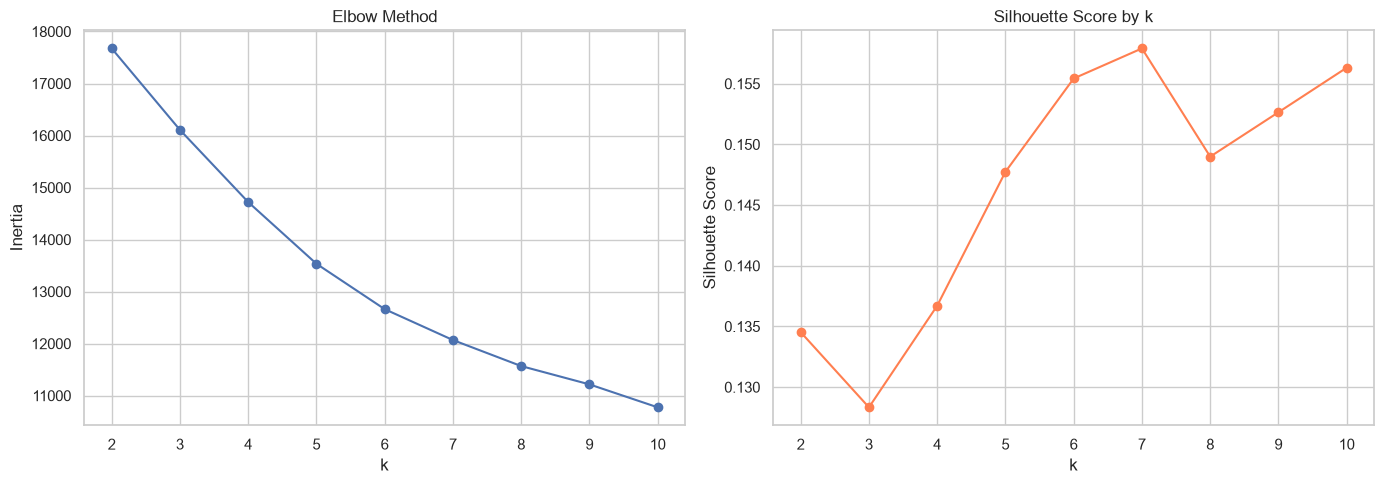

[2, 3, 4, 5, 6, 7, 8, 9, 10]
[17674.725152272058, 16108.454813850512, 14720.943095510933, 13534.59348361631, 12662.13764659391, 12068.380390217319, 11568.18123039218, 11216.315874425494, 10775.221784350035]
[0.13452811057807304, 0.12833377100563872, 0.13670711945515424, 0.147739339220693, 0.15542903045381798, 0.15790672178034723, 0.14898887548663425, 0.1526470344413902, 0.15631737886118793]


In [45]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")

axes[1].plot(list(k_range), silhouette_scores, marker="o", color="coral")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score by k")

plt.tight_layout()
plt.show()

print(list(k_range))
print(inertias)
print(silhouette_scores)

In [46]:
k_chosen = 7

kmeans = KMeans(n_clusters=k_chosen, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster)

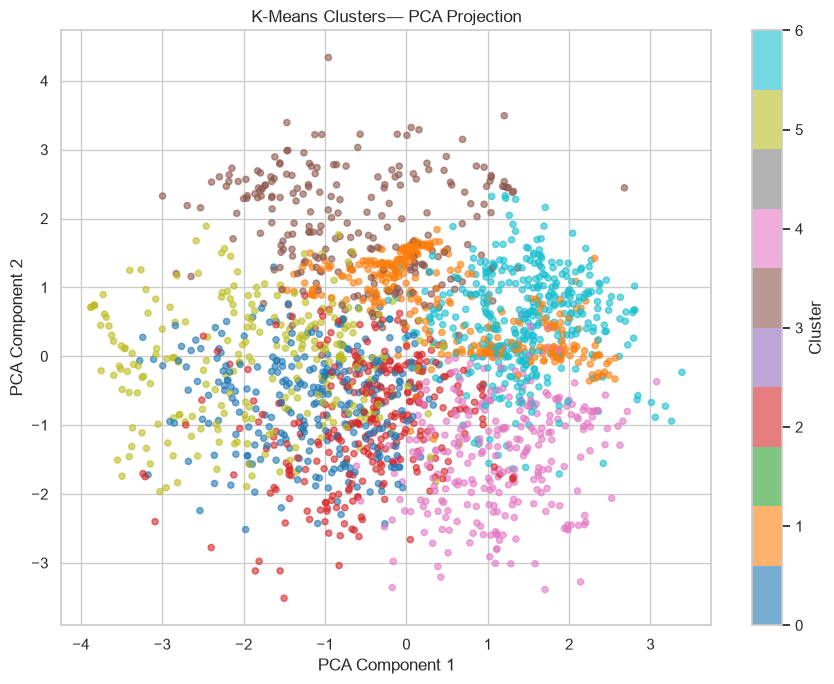

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap="tab10", alpha=0.6, s=20
)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title(f"K-Means Clusters— PCA Projection")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()


In [48]:
y_cluster_true = pd.concat([y_train_ob, y_val_ob, y_test_ob], axis=0)
true_labels_text = le.inverse_transform(y_cluster_true)

crosstab = pd.crosstab(cluster_labels, true_labels_text)
print(crosstab)

col_0  Insufficient_Weight  Normal_Weight  Obesity_Type_I  Obesity_Type_II  \
row_0                                                                        
0                       91             83              35                5   
1                        0              0               1                0   
2                       54             71              51                1   
3                        2             14              67               45   
4                       78             66              42                0   
5                       47             47              54               28   
6                        0              6             101              218   

col_0  Obesity_Type_III  Overweight_Level_I  Overweight_Level_II  
row_0                                                             
0                     0                  40                   34  
1                   323                   3                    7  
2                     0      

Student Reasoning — Clustering 
1. How did you choose k? Quote the Elbow/silhouette evidence. 
From the silhouette score, the score peaks at k=7 (0.1579), which is the highest value from 2-10, while The elbow plot had a continuous steady decline with no sharp bends. 

2. Looking at the crosstab, do the unsupervised clusters resemble the real obesity levels? Where do they agree and where do they break down? 
The K means clustering alligned closely with the real labels only at the extremes. Cluster 1was extremely clean with 97% Obesity type III and Cluster 6 consisted of Obesity Type II and type I. The other clusters spread across multiple categories with no dominant class.

3. In a real public-health setting where labels are expensive to collect, what would these clusters be useful for?
In a real public heatlh setting, these clusters would be useful for assessing the clusters with dominant characteristics without testing every single individual in this class. For instance, Cluster 1 has 97% Obesity type III, these individuals should be prioritized for intervention automatically.


Answer in a few sentences each:

Supervised vs unsupervised: What did the classifier learn that K-Means could not, and vice-versa?
The supervised classifier had access to the true NObeyesdad labels during training so it could learn the exact decision boundaries that separated the categories, and also distinguisingh Overweight level I from Normal weight (8 misclassifications). K means did not have access to labels and could not separate the middle categories well, but was able to find the clusters with dominant classes.


Regression vs classification: How did evaluating a continuous target (tips) differ from evaluating a categorical one (obesity level)?
Classification needed accuracy and Macro - F1 since obesity categories have o meaningful numerical distance. Classification benefitted from the confusion matrices, to see which categories get confused with each other. The regression model required the RMSE (average error) and R^2(proportion of variance) and did not have access to matrices to see which categories get confused with each other.


Overfitting: Across all three tasks, where did you see the biggest train-vs-test gap, and what is the single most effective thing you did (or would do) to close it?
The biggest overfitting gap was in the first section with the Random roest regression.Train R² of 0.669 dropped to a negative R² (-0.189) on the test set, which was a failure. the most effective fix would be to find a gap where max_depth is not too shallow or deep, a setting which forces the trees to learn broader patterns rather than memorizing individual rows.
